In [ ]:
!pip install bertopic pandas sentence-transformers hdbscan spacy

In [ ]:
!python -m spacy download en_core_web_sm

In [3]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import spacy
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sentence_transformers import SentenceTransformer
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
with open('AllArticles.md', 'r', encoding='utf-8') as text: #Reading the file and storing it in a variable for later cleaning
    Articles = text.read()
print(Articles)

In [ ]:
import re
nlp = spacy.load("en_core_web_sm")

def clean_text(text):
    import re
    text = re.sub(r'\[.*?\]', '', text)  #removing any punctuation
    text = re.sub(r'\(.*?\)', '', text)
    text = text.strip()

    doc = nlp(text)

    # Split multi-word entities into individual tokens
    person_names = {
        word
        for ent in doc.ents
        if ent.label_ == 'PERSON'
        for word in ent.text.lower().split()
    }

    tokens = [
        token.lemma_.lower() for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.like_num
        and token.text.lower() not in person_names   # now matches individual words
        and token.lemma_.lower() not in custom_stops  # catches 'blank', 'study' etc.
        and token.pos_ in ['NOUN', 'ADJ', 'VERB', 'PROPN']
    ]
    return " ".join(tokens)

test = 'culture and people of the Southeastern territory before European contact in 1539. Sometime before 1858, these six skulls were donated to the City’s Phrenological Society, a separate entity to the University of Edinburgh, by Professor W. Byrd Powell (1799-1867), an American disciple of phrenology.blish links between their measurements, intellect and character traits. For several years, the University has been seeking ways to address this uncomfortable legacy and maintains it has carried out ‘one of the most ambitious and wide-ranging academically-led examinations of history and race undertaken in the UK’. The Race Review it commissioned is understood to be driving sustained and meaningful change at the University, including the creation of a response group to further consider and consult on its recommendations. The formal ceremony held this month (23 January) to hand over the six Muscogee skulls to the Nation’s Department of Culture and Humanities is a result of this process. The University believes it is the first ever international repatriation of ancestral remains to mainland United States.'
print (clean_text(test))

In [ ]:
Clean_Articles = clean_text(Articles) #Applying cleaning function to text

FinalArticle = Clean_Articles.split() #Changing the text into a list of strings so BERT can process it
print(FinalArticle) #Testing previous output

In [16]:
#Sentence Transformer
sentence_model = SentenceTransformer("paraphrase-mpnet-base-v2")

#HDBSCAN Clustering
hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    prediction_data=True
)

#KeyBERTInspired Representation
representation_model = KeyBERTInspired()

#Fit BERTopic
model = BERTopic(
    language="english",
    embedding_model=sentence_model,
    hdbscan_model=hdbscan_model,
    representation_model=representation_model,
    nr_topics="auto"
)

topics, probs = model.fit_transform(FinalArticle)
print(f"\nDone!")
print(f"Topics found:          {len(set(topics)) - 1}")
print(f"Outlier titles (−1):   {topics.count(-1)}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/paraphrase-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Done!
Topics found:          229
Outlier titles (−1):   575


In [17]:
print (model.get_topic_info())

     Topic  Count                                    Name  \
0       -1    575              -1_woman_partner_week_want   
1        0    891     0_involve_comprise_engage_represent   
2        1    284     1_return_returning_recover_recovery   
3        2    200            2_british_britain_uk_anglian   
4        3    177  3_history_historical_historic_heritage   
..     ...    ...                                     ...   
225    224     15                  224_member_affiliate__   
226    225     15                            225_group___   
227    226     15     226_northern_north_northwest_northw   
228    227     15    227_prove_proof_demonstrate_evidence   
229    228     15                            228_spear___   

                                        Representation  \
0    [woman, partner, week, want, presence, united,...   
1    [involve, comprise, engage, represent, underta...   
2    [return, returning, recover, recovery, restore...   
3    [british, britain, uk, anglian

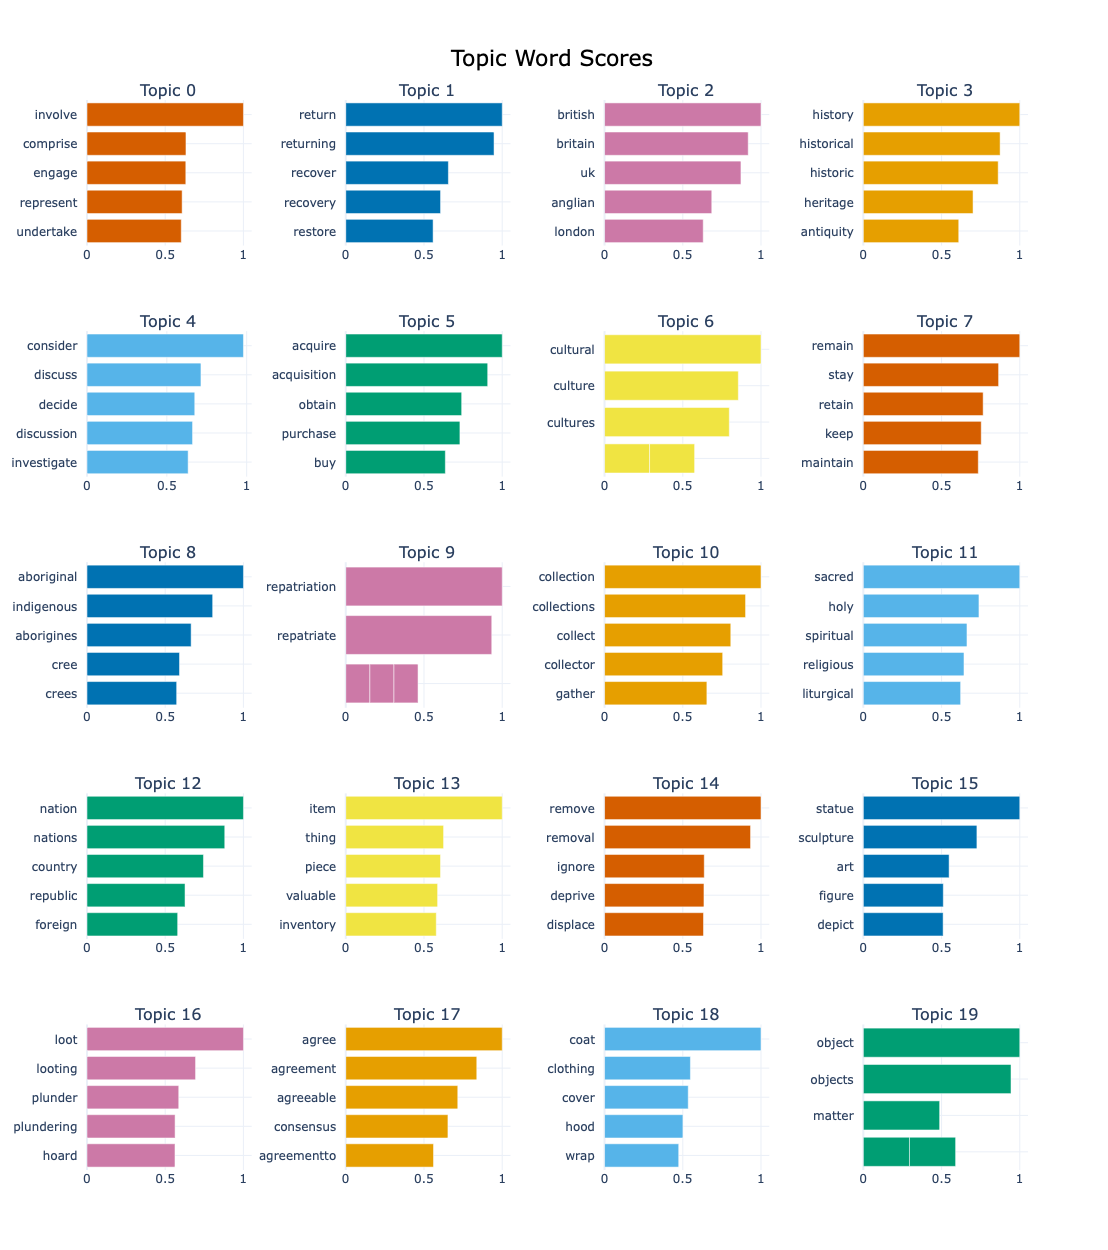

In [18]:
fig = model.visualize_barchart(top_n_topics=20)
fig.show()